In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def random_symmetric_bernoulli(n):
    # Generate upper triangle (including diagonal)
    upper = 2*np.random.binomial(1, p=0.5, size=(n, n))-1
    
    # Make it symmetric: A = upper + upper.T - diag
    A = np.triu(upper) + np.triu(upper, 1).T
    
    return A

In [38]:
n = 1000
A = random_symmetric_bernoulli(n)
A

array([[ 1, -1, -1, ...,  1, -1,  1],
       [-1,  1,  1, ...,  1, -1, -1],
       [-1,  1,  1, ...,  1,  1,  1],
       ...,
       [ 1,  1,  1, ...,  1,  1,  1],
       [-1, -1,  1, ...,  1, -1, -1],
       [ 1, -1,  1, ...,  1, -1, -1]], shape=(1000, 1000))

In [39]:
λ = np.linalg.eigvalsh(A)
λ

array([-6.28514615e+01, -6.27872256e+01, -6.19248666e+01, -6.16962023e+01,
       -6.15011873e+01, -6.06484179e+01, -6.02517673e+01, -6.01470997e+01,
       -5.94514024e+01, -5.92793173e+01, -5.91394272e+01, -5.89995473e+01,
       -5.86874054e+01, -5.80529002e+01, -5.78482412e+01, -5.75817397e+01,
       -5.73576413e+01, -5.71782759e+01, -5.69337101e+01, -5.68753766e+01,
       -5.63283854e+01, -5.63076628e+01, -5.62180477e+01, -5.58501205e+01,
       -5.54618580e+01, -5.53025791e+01, -5.52256715e+01, -5.51646600e+01,
       -5.48301244e+01, -5.46697712e+01, -5.44828015e+01, -5.43169970e+01,
       -5.41265980e+01, -5.38777675e+01, -5.38162260e+01, -5.36335854e+01,
       -5.34401488e+01, -5.31469205e+01, -5.29097738e+01, -5.28044001e+01,
       -5.23439538e+01, -5.23052077e+01, -5.22514419e+01, -5.18978985e+01,
       -5.17633050e+01, -5.16047304e+01, -5.14830342e+01, -5.13842096e+01,
       -5.10912927e+01, -5.09759593e+01, -5.08716752e+01, -5.07863057e+01,
       -5.06582352e+01, -

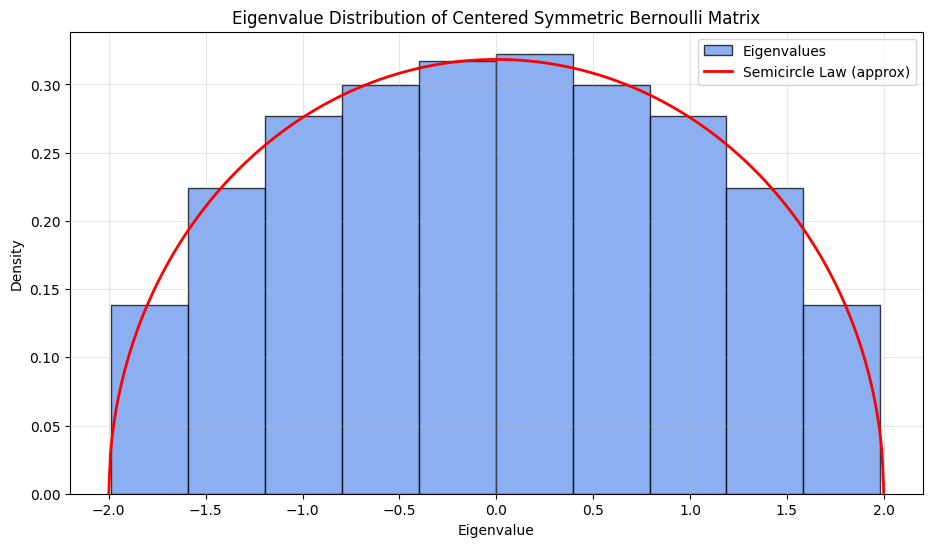

In [40]:
plt.figure(figsize=(11, 6))
plt.hist(λ/np.sqrt(n), bins=10, density=True, alpha=0.75, 
         color='cornflowerblue', edgecolor='black', label='Eigenvalues')

# Semicircle law approximation (for large n)
x = np.linspace(-2, 2, 500)
semicircle = (1/(2*np.pi)) * np.sqrt(4 - x**2)
plt.plot(x, semicircle, 'r-', lw=2, label='Semicircle Law (approx)')

plt.title('Eigenvalue Distribution of Centered Symmetric Bernoulli Matrix')
plt.xlabel('Eigenvalue')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()